## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import random

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

which_dataset = config["which_dataset"]
preprocessing_method = config["preprocessing_method"] # normalization / logarithm
remove_outer_bool = config["remove_outer"]
how_many_outer_to_remove = config["how_many_outer_to_remove"]
elements_to_keep = config["elements_to_keep"][which_dataset]

data_path = config["data_path"][which_dataset]
results_path = config["results_path"]
figures_path = config["figures_path"]
models_path = config["models_path"][which_dataset]

In [3]:
columns_to_keep_inds = [el + '_i' for el in elements_to_keep]
columns_to_keep_inks = [el + '_a' for el in elements_to_keep]

## Loading the data

In [4]:
df = pd.read_csv(data_path)
inks_df = df[[col for col in df.columns if col.endswith('_a')]]
inks_df.columns = [col.split('_')[0] for col in inks_df.columns]
inds_df = df[[col for col in df.columns if col.endswith('_i')]]
inds_df.columns = [col.split('_')[0] for col in inds_df.columns]

if which_dataset == 'old':
    df['sample_i'] = df['inds'].apply(lambda x: x.split('.')[0])
    df['sample_a'] = df['sample_i']
    df.rename(columns={'inds': 'name'}, inplace=True)

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [5]:
inDKs_df = df

### Keeping track of the records from the same sample

Check

In [6]:
if which_dataset == 'old':
    all(inDKs_df['sample_i'] == inDKs_df['sample_a'])
if which_dataset == 'new':
    all(inDKs_df['name_i'].apply(lambda x: (x.split('_')[0]).split('.')[0]) == inDKs_df['name_a'].apply(lambda x: (x.split('_')[0]).split('.')[0]))

We can use adjusted 'name' column as sample id:

In [7]:
if which_dataset == 'old':
    inDKs_df['Sample_id'] = inDKs_df['sample_i']
if which_dataset == 'new':
    inDKs_df['Sample_id'] = inDKs_df['name_i'].apply(lambda x: (x.split('_')[0]).split('.')[0])
    inDKs_df['name'] = inDKs_df['Sample_id'] + '_' + inDKs_df['name_i'].apply(lambda x: x.split('_')[-1])

### Removing some data

1. Let's remove 'outer' samples:

In [8]:
def remove_outer(group, n):
    return group.iloc[n:-n] if len(group) > 2*n else pd.DataFrame(columns=group.columns)

In [9]:
if remove_outer_bool:
    inDKs_df = inDKs_df.groupby('Sample_id', group_keys=False).apply(remove_outer, n=how_many_outer_to_remove)

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [10]:
inDKs_df = inDKs_df[columns_to_keep_inks + columns_to_keep_inds + ['Sample_id', 'name'] ]

3. Let's remove rows with missing values.

In [11]:
(inDKs_df.shape[0] - inDKs_df.dropna().shape[0])/inDKs_df.shape[0]

0.0

4. Let's set negative numbers to zeros. (First, check if there are any.)

In [12]:
(inDKs_df[columns_to_keep_inks + columns_to_keep_inds]<0).sum().sum() == 0

np.True_

In [13]:
for col in columns_to_keep_inks + columns_to_keep_inds:
    inDKs_df[col][inDKs_df[col] < 0] = 0

/tmp/ipykernel_11715/1556174307.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  inDKs_df[col][inDKs_df[col] < 0] = 0
/tmp/ipykernel_11715/1556174307.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

5. Let's multiply the values by weights.

In [16]:
if which_dataset == "new":
    
    #Al, S, Cr, Mn, Co, Cu, Zn, Pb, Fe, Mg
    custom_weights = [1, 1, 1, 10, 19, 20, 17, 9, 20, 1]
    weights = [el/sum(custom_weights) for el in custom_weights]
    
    for i, col in enumerate(columns_to_keep_inds):
        inDKs_df[col] = weights[i]*inDKs_df[col]
    for i, col in enumerate(columns_to_keep_inks):
        inDKs_df[col] = weights[i]*inDKs_df[col]

6. Normalize with respect to Fe and remove Fe.

In [17]:
# for i, col in enumerate(columns_to_keep_inks):
#     inDKs_df[col] = inDKs_df[col] / inDKs_df['Fe_a']

In [18]:
# for i, col in enumerate(columns_to_keep_inds):
#     inDKs_df[col] = inDKs_df[col] / inDKs_df['Fe_i']

In [19]:
# inDKs_df.drop(columns=['Fe_a', 'Fe_i'], inplace=True)
# columns_to_keep_inks.remove('Fe_a')
# columns_to_keep_inds.remove('Fe_i')

### Train test split, datasets, dataloaders

In [20]:
indices = list(range(int(inDKs_df.shape[0])))
ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

partition = {'train': ind_train_all,
         'val': ind_val_all,
        'test': ind_test_all}

X_y_train = inDKs_df.iloc[partition['train'],:]
X_y_val = inDKs_df.iloc[partition['val'],:]
X_y_test = inDKs_df.iloc[partition['test'],:]

X_y_train.reset_index(drop=True, inplace=True)
X_y_val.reset_index(drop=True, inplace=True)
X_y_test.reset_index(drop=True, inplace=True)

### Creating features and labels matrices

In [21]:
train_order = X_y_train['Sample_id']
val_order = X_y_val['Sample_id']
test_order = X_y_test['Sample_id']

X_train = np.array(X_y_train[columns_to_keep_inds].values)
y_train = np.array(X_y_train[columns_to_keep_inks].values)
X_val = np.array(X_y_val[columns_to_keep_inds].values)
y_val = np.array(X_y_val[columns_to_keep_inks].values)
X_test = np.array(X_y_test[columns_to_keep_inds].values)
y_test = np.array(X_y_test[columns_to_keep_inks].values)

### Normalization / taking logarithm

In [22]:
def adjusted_log_transform(input_array):
    res = np.where(input_array>0, np.log(input_array), 0.)
    return res

In [23]:
if preprocessing_method == 'normalization':

    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X_train = adjusted_log_transform(X_train)
    y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
elif preprocessing_method == 'logarithm_and_normalization':
    
    #logarithm
    X_train = adjusted_log_transform(X_train)
    y_train = adjusted_log_transform(y_train)
    
    X_val = adjusted_log_transform(X_val)
    y_val = adjusted_log_transform(y_val)
    X_test = adjusted_log_transform(X_test)
    y_test = adjusted_log_transform(y_test)
    
    #normalization
    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    y_train = (y_train - np.min(y_train, axis=0))/np.std(y_train, axis=0)

    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    y_val = (y_val - np.min(y_val, axis=0))/np.std(y_val, axis=0)

    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    y_test = (y_test - np.min(y_test, axis=0))/np.std(y_test, axis=0)

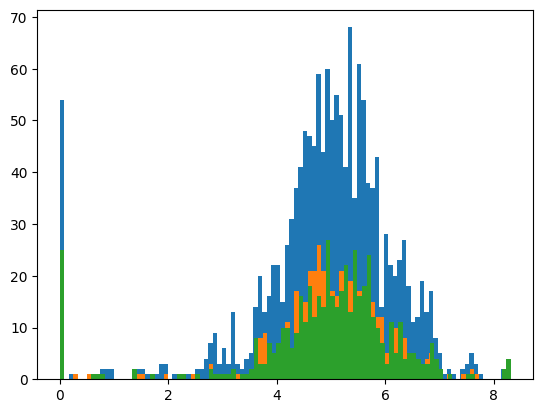

In [24]:
dim = 0
plt.hist(X_train[:,dim], bins=100);
plt.hist(X_test[:,dim], bins=100);
plt.hist(X_val[:,dim], bins=100);

#np.argwhere(X_train[:,2]<-20)

### Converting to tensors

In [25]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [26]:
X_train = torch.Tensor(X_train).to(device)
y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

### Dataset

In [27]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [28]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [29]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [30]:
input_size = X_train.shape[1]

For now, we keep only use very simple neural network. The layers are lineaer, each has the same number of neurons equal to the size of input (and, at the same time, size of output).

In [31]:
dropout_prob = 0.02

class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 256),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(256, 512),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(512, 1024),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(1024, 512),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.Dropout(dropout_prob),
        nn.ReLU(),
        nn.Linear(32, input_size))
    def forward(self, x):
        return self.seq(x)

## Training

In [32]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): Dropout(p=0.02, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): Dropout(p=0.02, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=128, bias=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=256, bias=True)
    (10): Dropout(p=0.02, inplace=False)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=512, bias=True)
    (13): Dropout(p=0.02, inplace=False)
    (14): ReLU()
    (15): Linear(in_features=512, out_features=1024, bias=True)
    (16): Dropout(p=0.02, inplace=False)
    (17): ReLU()
    (18): Linear(in_features=1024, out_features=512, bias=True)
    (19): Dropout(p=0.02, inplace=False)
    (20): ReLU()
    (21): Linear(in_features=512, out_features=256, bias=True)
    (22): Dropout(p=0.02, inplace=False)
    (23): ReLU()
    (24): Linea

In [33]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

In [34]:
weights = torch.tensor([1/input_size]*input_size).unsqueeze(1).to(device)
# custom_weights = [1, 1, 1, 10, 19, 20, 17, 9, 20, 1]
# weights = torch.tensor([el/sum(custom_weights) for el in custom_weights]).unsqueeze(1).to(device)
#Al, S, Cr, Mn, Co, Cu, Zn, Pb, Fe, Mg
#1, 1, 1, 10, 19, 20, 17, 9, 20, 1

class CustomLoss(nn.Module):
    def __init__(self, weights=weights):
        super(CustomLoss, self).__init__()
        self.weights = weights
        assert weights.shape[1] == 1

    def forward(self, outputs, targets):
        inner_loss = nn.L1Loss(reduction='none')
        res = inner_loss(outputs, targets)
        res = torch.mm(res, self.weights)
        res = res.mean(axis=0)
#         inner_loss_to_compare = nn.L1Loss(reduction='mean')
#         assert torch.isclose(inner_loss_to_compare(outputs, targets), res)
        return res

In [35]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 6.094620863596599 test 3.533371371155283
EPOCH 2:
LOSS train 2.4502196391423543 test 1.7732982909463975
EPOCH 3:
LOSS train 1.7402785857518515 test 1.3734100581591866
EPOCH 4:
LOSS train 1.5595409790674846 test 1.23578536888203
EPOCH 5:
LOSS train 1.4697422504425048 test 1.3250858472993814
EPOCH 6:
LOSS train 1.4164165019989015 test 1.1868514890932893
EPOCH 7:
LOSS train 1.364612921079 test 1.3100301258864413
EPOCH 8:
LOSS train 1.346644139289856 test 1.2607441395455334
EPOCH 9:
LOSS train 1.3709575335184734 test 1.114885252243484
EPOCH 10:
LOSS train 1.3129472335179646 test 1.2235012579428024
EPOCH 11:
LOSS train 1.3064569393793741 test 1.1740602366288893
EPOCH 12:
LOSS train 1.2810108502705893 test 1.0860151963020455
EPOCH 13:
LOSS train 1.3046756982803345 test 1.0814943746578727
EPOCH 14:
LOSS train 1.2866092443466186 test 1.0869324012283221
EPOCH 15:
LOSS train 1.2616856813430786 test 1.1817625492989239
EPOCH 16:
LOSS train 1.2510465224583944 test 1.087075948531

In [37]:
EPOCHS = 5000
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 4.902619921244108 test 2.3000205353895824
EPOCH 2:
LOSS train 1.8109508890372057 test 1.5236489988128905
EPOCH 3:
LOSS train 1.5296284418839674 test 1.2601121139512375
EPOCH 4:
LOSS train 1.4748322734465966 test 1.3922244871222358
EPOCH 5:
LOSS train 1.4779299268355737 test 1.1955335151666486
EPOCH 6:
LOSS train 1.4234985525791461 test 1.2777812114525848
EPOCH 7:
LOSS train 1.3968614798325758 test 1.183426933280529
EPOCH 8:
LOSS train 1.3877428770065308 test 1.2913294813645557
EPOCH 9:
LOSS train 1.3998489334033086 test 1.1854735909363892
EPOCH 10:
LOSS train 1.3601056658304655 test 1.182972902867226
EPOCH 11:
LOSS train 1.3687388346745417 test 1.188223887083466
EPOCH 12:
LOSS train 1.3186151797954853 test 1.2249535423104472
EPOCH 13:
LOSS train 1.3205268749823937 test 1.1697897836660414
EPOCH 14:
LOSS train 1.3322380964572613 test 1.341377546478745
EPOCH 15:
LOSS train 1.3172361254692078 test 1.42342442637598
EPOCH 16:
LOSS train 1.3296476694253774 test 1.190148342

In [34]:
EPOCHS = 1500
#loss_fn = nn.L1Loss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss*(1-dropout_prob)))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 4.3746999104817705 test 2.407649113495187
EPOCH 2:
LOSS train 1.9688400189081827 test 1.4455053245386924
EPOCH 3:
LOSS train 1.4544131596883139 test 1.245430450621379
EPOCH 4:
LOSS train 1.3491501649220785 test 1.1926037243439491
EPOCH 5:
LOSS train 1.3396738688151042 test 1.2504748680505409
EPOCH 6:
LOSS train 1.2801364342371622 test 1.1922589741078726
EPOCH 7:
LOSS train 1.2688172976175944 test 1.1877359192593988
EPOCH 8:
LOSS train 1.2635023276011148 test 1.1745499463911995
EPOCH 9:
LOSS train 1.2523108005523682 test 1.116329320679946
EPOCH 10:
LOSS train 1.2289135853449504 test 1.139686885620935
EPOCH 11:
LOSS train 1.2147783438364665 test 1.1387445480600897
EPOCH 12:
LOSS train 1.2092183033625286 test 1.06690972389586
EPOCH 13:
LOSS train 1.2047888358434042 test 1.1535104167138237
EPOCH 14:
LOSS train 1.1924776792526246 test 1.0653950708254754
EPOCH 15:
LOSS train 1.180717118581136 test 1.060296455286593
EPOCH 16:
LOSS train 1.1880490144093832 test 1.0887964289

In [ ]:
##############################################################################

#### Loss visualisation

Below: plots of train loss (blue) and validation loss (orange) for different neural networks that have been tested so far. Horizontal axis corresponds to epoch number.

In [35]:
#%matplotlib widget

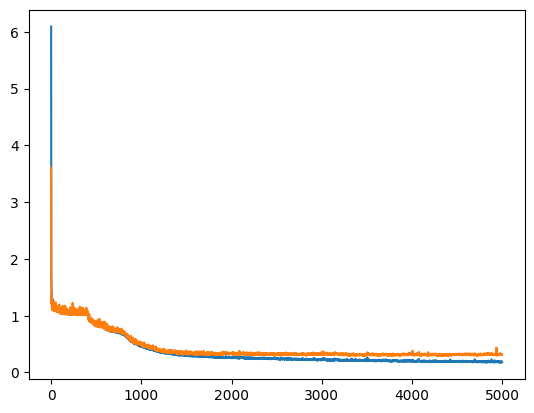

In [36]:
plt.plot(train_losses)
plt.plot(val_losses)

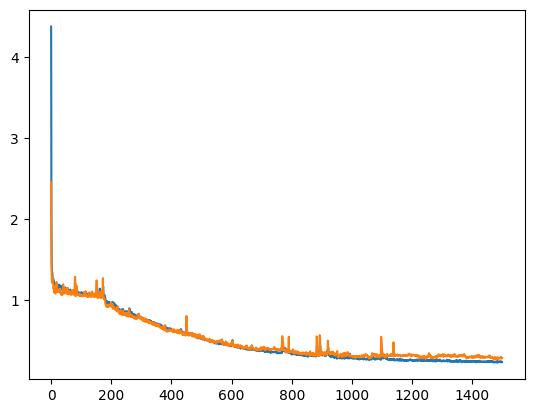

In [35]:
plt.plot(train_losses)
plt.plot(val_losses)

## Loading pretrained model

In [38]:
# model = InksNet().to(device)
# model.load_state_dict(torch.load(models_path))

/tmp/ipykernel_8927/723805453.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path))


<All keys matched successfully>

## Prediction on test set

In [37]:
model.eval()
loss_fn = CustomLoss()

running_tloss = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    if i==0:
        out = outputs
        lab = labels
        res = abs(outputs-labels)
    else:
        res = torch.concat((res, abs(outputs-labels)), axis=0)
        lab = torch.concat((lab, labels), axis=0)
        out = torch.concat((out, outputs), axis=0)
    running_tloss += loss.item()
    
mean_loss = running_tloss/len(test_loader)

Consecutive inks from test set are in lab tensor (484 examples, 8 elements/coordinates):

In [38]:
lab

tensor([[ 8.4423,  6.2110,  0.8139,  ...,  7.2532, 12.7834,  9.5012],
        [ 9.2529,  6.7072,  1.6522,  ...,  9.5907, 12.6791,  9.2599],
        [ 7.7860,  6.3128,  0.1764,  ...,  6.5997, 12.3654,  8.8049],
        ...,
        [ 8.3831,  6.4586,  0.8281,  ...,  7.5516, 11.9691,  9.3459],
        [10.0224,  8.0365,  2.5609,  ...,  9.0747, 14.0314, 10.5735],
        [ 8.6278,  6.9695,  0.6588,  ...,  7.8435, 11.7739,  8.9485]],
       device='cuda:0')

Predictions are in out tensor (484 examples, 8 elements/coordinates):

In [39]:
out

tensor([[ 8.4970,  6.2857,  1.1043,  ...,  7.2086, 12.7585,  9.2821],
        [ 9.0979,  6.6430,  2.1613,  ...,  9.2075, 12.6612,  9.1722],
        [ 7.8230,  6.4792,  0.1458,  ...,  6.6398, 12.2935,  8.9570],
        ...,
        [ 8.6740,  6.5981,  1.7215,  ...,  7.9476, 12.0160,  9.1443],
        [ 9.9408,  8.1194,  2.5683,  ...,  8.9821, 13.8793, 10.4654],
        [ 8.5773,  6.8482,  0.6476,  ...,  7.4455, 11.7992,  9.0382]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (lab) and prediction (out) are stored in res tensor (484 examples, 8 elements/coordinates):

In [40]:
res

tensor([[0.0547, 0.0747, 0.2904,  ..., 0.0446, 0.0249, 0.2191],
        [0.1551, 0.0642, 0.5091,  ..., 0.3833, 0.0180, 0.0877],
        [0.0370, 0.1664, 0.0306,  ..., 0.0401, 0.0719, 0.1521],
        ...,
        [0.2910, 0.1395, 0.8934,  ..., 0.3960, 0.0469, 0.2016],
        [0.0816, 0.0829, 0.0074,  ..., 0.0926, 0.1521, 0.1081],
        [0.0505, 0.1212, 0.0112,  ..., 0.3981, 0.0253, 0.0897]],
       device='cuda:0', grad_fn=<CatBackward0>)

To calculate mean error on consecutive coordinates run:

In [40]:
torch.mean(res, axis=0)  # 8 elements, old data

tensor([0.2338, 0.1530, 0.3298, 0.1149, 0.1917, 0.2002, 0.2166, 0.1863],
       device='cuda:0', grad_fn=<MeanBackward1>)

In [44]:
torch.mean(res, axis=0)  # 6 elements, new_data

tensor([0.2166, 0.2643, 0.5870, 0.2188, 0.2698, 0.2533, 0.2983, 0.2568, 0.2661,
        0.2072], device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

Later on we will modify loss function so that errors from coordinates will be weighted depending on the importance of chemical elements.

To calculate mean error on all coordinates run:

In [41]:
torch.mean(res) # 8 elements, old data

tensor(0.2033, device='cuda:0', grad_fn=<MeanBackward0>)

In [71]:
torch.mean(res) # 10 elements, old data

tensor(0.2838, device='cuda:0', grad_fn=<MeanBackward0>)

## Saving the model

In [72]:
outer_removed = 'outer_removed' if remove_outer else 'outer_not_removed'

elements = '_'.join(elements_to_keep)
settings_str = '_' + preprocessing_method + '_' + \
                outer_removed + '_' + str(how_many_outer_to_remove) + \
                '_' + elements + '_'

import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

torch.save(model.state_dict(), '/'.join(models_path.split('/')[:-1]) + '/model_regression' + settings_str + now)

### Visualisations

In [43]:
dim_nr = 7
selected_outputs = out[:, dim_nr].cpu().detach().numpy()
selected_labels = lab[:, dim_nr].cpu().detach().numpy()

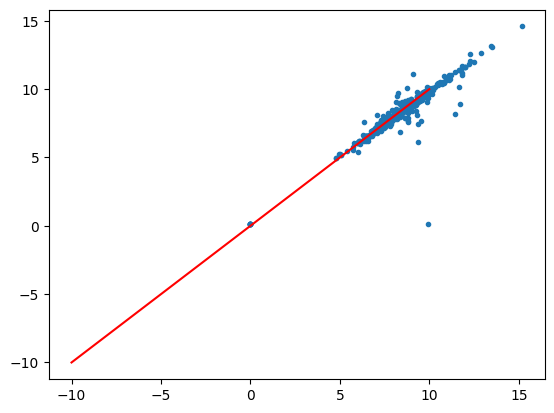

In [44]:
plt.plot(selected_labels, selected_outputs, '.')
plt.plot( [-10, 10],[-10, 10], 'red' )

## Quality of prediction: closest points

#### Creating df with means of classes

In [45]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds]

In [46]:
train_val_df = pd.DataFrame(y_train.cpu())
train_val_df = pd.concat([train_val_df, 
                                    pd.DataFrame(y_val.cpu())])
train_val_df.columns = elements_names
train_val_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
train_val_df.reset_index(drop=True, inplace=True)

In [47]:
mean_df = train_val_df[['Sample_id']]

for name in elements_names:
    mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
    mean_df.drop_duplicates('Sample_id', inplace=True)

mean_df['Sample_id'] = mean_df['Sample_id'].astype(str)
mean_df.sort_values(by='Sample_id', inplace=True)
mean_df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_11715/1503384335.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df[name] = train_val_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_11715/1503384335.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_11715/1503384335.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

#### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [48]:
y_test_df = pd.DataFrame(y_test.cpu())
y_test_df.columns = elements_names
y_test_df.insert(0, 'Sample_id', test_order)
y_test_df.reset_index(drop=True, inplace=True)

In [49]:
closest = []
for i in range(y_test_df.shape[0]):
    which_row = (abs(y_test_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [50]:
len(closest)

498

In [51]:
y_test_df['Closest'] = closest

In [52]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] 

477

In [53]:
y_test_df[y_test_df['Sample_id'] == y_test_df['Closest']].shape[0] / len(closest)

0.9578313253012049

#### Now let's check if it works for the neural network's output.

In [54]:
model.eval()
outputs = model(X_test)

In [55]:
outputs_df = pd.DataFrame(outputs.cpu().detach().numpy())
outputs_df.columns = elements_names
outputs_df.insert(0, 'Real sample_id', test_order)
outputs_df['Real sample_id'] = outputs_df['Real sample_id'].astype(str)
outputs_df.reset_index(drop=True, inplace=True)

In [56]:
closest = []
for i in range(outputs_df.shape[0]):
    which_row = (abs(outputs_df.iloc[i, 1:] - mean_df.iloc[:,1:])).sum(1).idxmin()
    closest.append(mean_df.iloc[which_row]['Sample_id'])

In [57]:
len(closest)

498

In [58]:
outputs_df['Closest'] = closest

In [62]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0]

435

In [63]:
outputs_df[y_test_df['Sample_id'] == outputs_df['Closest']].shape[0] / len(closest) #1024, dropout 0.01

0.8734939759036144

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from seaborn import heatmap

In [65]:
acc = np.round(100*outputs_df[outputs_df['Real sample_id'] == outputs_df['Closest']].shape[0] / len(closest), 1)
print('Accuracy: '+str(acc)+'%.')

Accuracy: 87.3%.


In [66]:
normalization_in_conf_mat = None

conf_mat = confusion_matrix(outputs_df['Real sample_id'], outputs_df['Closest'], 
                            normalize=normalization_in_conf_mat)

tp_and_fn = conf_mat.sum(1)
tp_and_fp = conf_mat.sum(0)
tp = conf_mat.diagonal()

precision = tp / tp_and_fp
recall = tp / tp_and_fn

print('Precision: ' + str(np.nanmean(precision)))
print('Recall: ' + str(np.nanmean(recall)))

Precision: 0.9055810397553518
Recall: 0.886904761904762


/tmp/ipykernel_8927/2917754103.py:10: RuntimeWarning: invalid value encountered in divide
  precision = tp / tp_and_fp
/tmp/ipykernel_8927/2917754103.py:11: RuntimeWarning: invalid value encountered in divide
  recall = tp / tp_and_fn


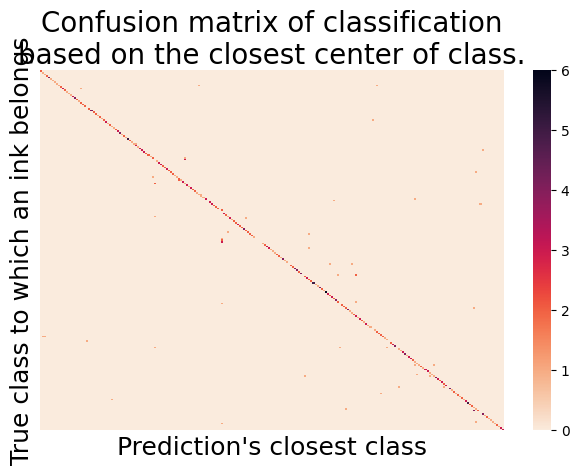

In [67]:
normalization_in_conf_mat = None
scores = {
            'pred': 'Precision',
            'true': 'Recall',
            None: 'Confusion matrix'
            }

conf_mat = confusion_matrix(outputs_df['Real sample_id'], outputs_df['Closest'], 
                            normalize=normalization_in_conf_mat)

heatmap(conf_mat, cmap=sns.cm.rocket_r, xticklabels=False, yticklabels=False)
plt.ylabel('True class to which an ink belongs', size=18)
plt.xlabel("Prediction's closest class", size=18)
plt.rcParams['figure.figsize'] = [15, 10]
plt.title(scores[normalization_in_conf_mat] + ' of classification based on the closest center of class.', 
          size=20, 
          wrap=True)

plt.tight_layout()
#plt.savefig('../figures/heatmap_' + scores[normalization_in_conf_mat] + '.png')

## Quality of prediction: confidence intervals

In [68]:
model.eval()
outputs = model(X_test)

In [69]:
elements_names = [el.split('_')[0] for el in columns_to_keep_inds]

In [70]:
all_data_df = pd.DataFrame(y_train.cpu())
all_data_df = pd.concat([all_data_df, 
                        pd.DataFrame(y_val.cpu())])
all_data_df.columns = elements_names
all_data_df.insert(0, 'Sample_id', pd.concat([train_order, val_order]))
all_data_df.reset_index(drop=True, inplace=True)

In [71]:
min_max_df = all_data_df[['Sample_id']]

for name in elements_names:
    min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    min_max_df[name + '_min'] = all_data_df.groupby('Sample_id')[name].transform('min')
    min_max_df.drop_duplicates('Sample_id', inplace=True)
        
min_max_df.sort_values(by='Sample_id', inplace=True)
min_max_df.reset_index(drop=True, inplace=True)

max_df = min_max_df.iloc[:,1:(1+len(elements_names))]
max_df['Sample_id'] = min_max_df['Sample_id']
min_df = min_max_df.iloc[:,1+len(elements_names):]
min_df['Sample_id'] = min_max_df['Sample_id']

/tmp/ipykernel_8927/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df[name + '_max'] = all_data_df.groupby('Sample_id')[name].transform('max')
/tmp/ipykernel_8927/3264826654.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  min_max_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_8927/3264826654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/sta

In [72]:
mean_sd_df = all_data_df[['Sample_id']]

for name in elements_names:
    mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
for name in elements_names:
    mean_sd_df[name + '_sd'] = all_data_df.groupby('Sample_id')[name].transform(np.std)
    mean_sd_df.drop_duplicates('Sample_id', inplace=True)
    
mean_sd_df.sort_values(by='Sample_id', inplace=True)
mean_sd_df.reset_index(drop=True, inplace=True)

upper_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values + \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
upper_bound_df = pd.DataFrame(upper_bound_df, columns=elements_names)
upper_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

lower_bound_df = mean_sd_df.iloc[:,1:(1+len(elements_names))].values - \
                2*mean_sd_df.iloc[:,1+len(elements_names):].values
lower_bound_df = pd.DataFrame(lower_bound_df, columns=elements_names)
lower_bound_df['Sample_id'] = mean_sd_df[['Sample_id']]

/tmp/ipykernel_8927/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df[name + '_mean'] = all_data_df.groupby('Sample_id')[name].transform('mean')
/tmp/ipykernel_8927/2008320981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mean_sd_df.drop_duplicates('Sample_id', inplace=True)
/tmp/ipykernel_8927/2008320981.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [73]:
min_max_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater_than_min = test_example.cpu().detach().numpy() > \
                    np.array(min_df.loc[min_df['Sample_id'] == sample_id, min_df.columns != 'Sample_id'])
    
    less_than_max = test_example.cpu().detach().numpy() < \
                    np.array(max_df.loc[max_df['Sample_id'] == sample_id, max_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater_than_min, less_than_max)
    
    #print(res)
    min_max_res_list.append(res)

In [74]:
sd_res_list = []
for test_example, sample_id in zip(outputs, test_order):
    
    greater = test_example.cpu().detach().numpy() > \
    np.array(lower_bound_df.loc[lower_bound_df['Sample_id'] == sample_id, lower_bound_df.columns != 'Sample_id'])
    
    less = test_example.cpu().detach().numpy() < \
    np.array(upper_bound_df.loc[upper_bound_df['Sample_id'] == sample_id, upper_bound_df.columns != 'Sample_id'])
    
    res = np.logical_and(greater, less)
    
    #print(res)
    sd_res_list.append(res)

In [75]:
elements_names

['Al', 'S', 'Cr', 'Mn', 'Co', 'Cu', 'Zn', 'Pb', 'Fe', 'Mg']

Percentage of points inside mean +- 2 standard deviations interval:

In [76]:
np.array(sd_res_list).mean()

np.float64(0.7516064257028112)

On consecutive coordinates:

In [77]:
np.array(sd_res_list).mean(0)

array([[0.71686747, 0.82128514, 0.85943775, 0.73493976, 0.77108434,
        0.70481928, 0.78915663, 0.69076305, 0.62048193, 0.80722892]])

Percentage of points inside min-max interval:

In [78]:
np.array(min_max_res_list).mean()

np.float64(0.6124497991967871)

On consecutive coordinates:

In [79]:
np.array(min_max_res_list).mean(0)

array([[0.57028112, 0.72289157, 0.78714859, 0.55421687, 0.63453815,
        0.5502008 , 0.67871486, 0.52008032, 0.40160643, 0.70481928]])

### Visualisations of mean +- 2 * standard deviation intervals

In [80]:
# fig, ax = plt.subplots(2,4, figsize=(15,8))
# plt.suptitle('Mean +- two standard deviations in classes')
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].hlines(y=sample_id, xmin=lower_bound_df.iloc[sample_id, element], 
#                   xmax=upper_bound_df.iloc[sample_id, element], 
#                   color="blue", linewidth=1)
#         ax[element//4][element%4].set_title(elements_names[element], size=15)
#         if element == 5:
#             ax[element//4][element%4].set_xlim([-0.2, 2.0])
#         if element == 0 or element == 4:
#             ax[element//4][element%4].set_ylabel('Class number')
    
#plt.savefig(figures_path + 'intervals.png', dpi=300)

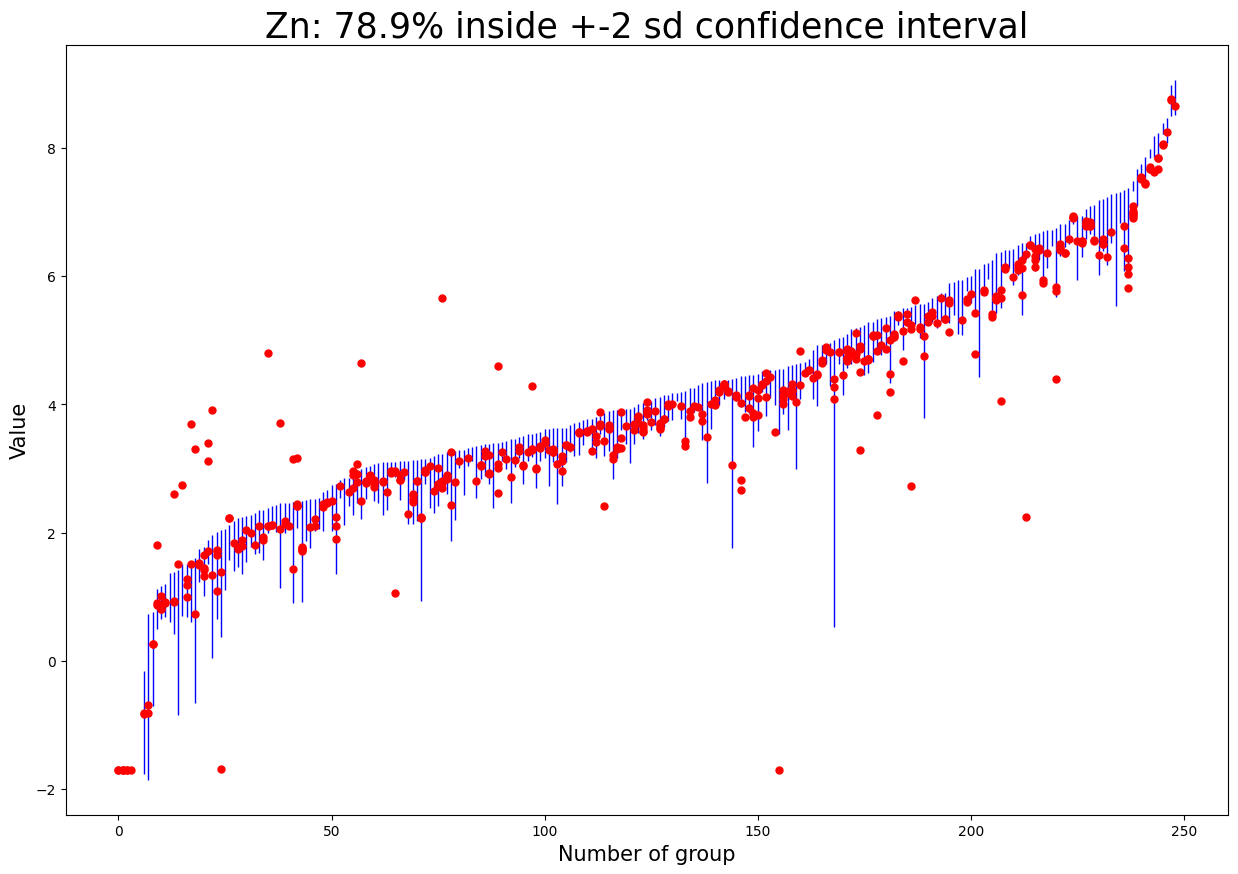

In [81]:
element = 6
percentage_correct = np.round(100*(np.array(sd_res_list).mean(0))[0,element], 1)

sorted_upper_bound_df = upper_bound_df.sort_values(upper_bound_df.columns[element])
sorted_upper_bound_df.reset_index(drop=True, inplace=True)
sorted_lower_bound_df = lower_bound_df.iloc[upper_bound_df.sort_values(upper_bound_df.columns[element]).index,:]
sorted_lower_bound_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_lower_bound_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_lower_bound_df.iloc[sample_id, element], 
                  ymax=sorted_upper_bound_df.iloc[sample_id, element], 
                  color="blue", linewidth=1)
    
for row in range(outputs_df.shape[0]):
    new_index = sorted_upper_bound_df[sorted_upper_bound_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xlabel('Number of group',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside +-2 sd confidence interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
#plt.savefig('../figures/confidence_intervals_'+str(outputs_df.columns[element+1]))

### Visualisations of min-max intervals

In [82]:
# fig, ax = plt.subplots(2,4, figsize=(10,5))
# for sample_id in range(min_max_df.shape[0]):
#     for element in range(int((min_max_df.shape[1]-1)/2)):
#         ax[element//4][element%4].vlines(x=sample_id, ymin=min_max_df.iloc[sample_id, element+9], 
#                   ymax=min_max_df.iloc[sample_id, element+1], 
#                   color="blue", linewidth=1)
        #ax[element%4][element%2].set_title(elements_names[element])

For a single element:

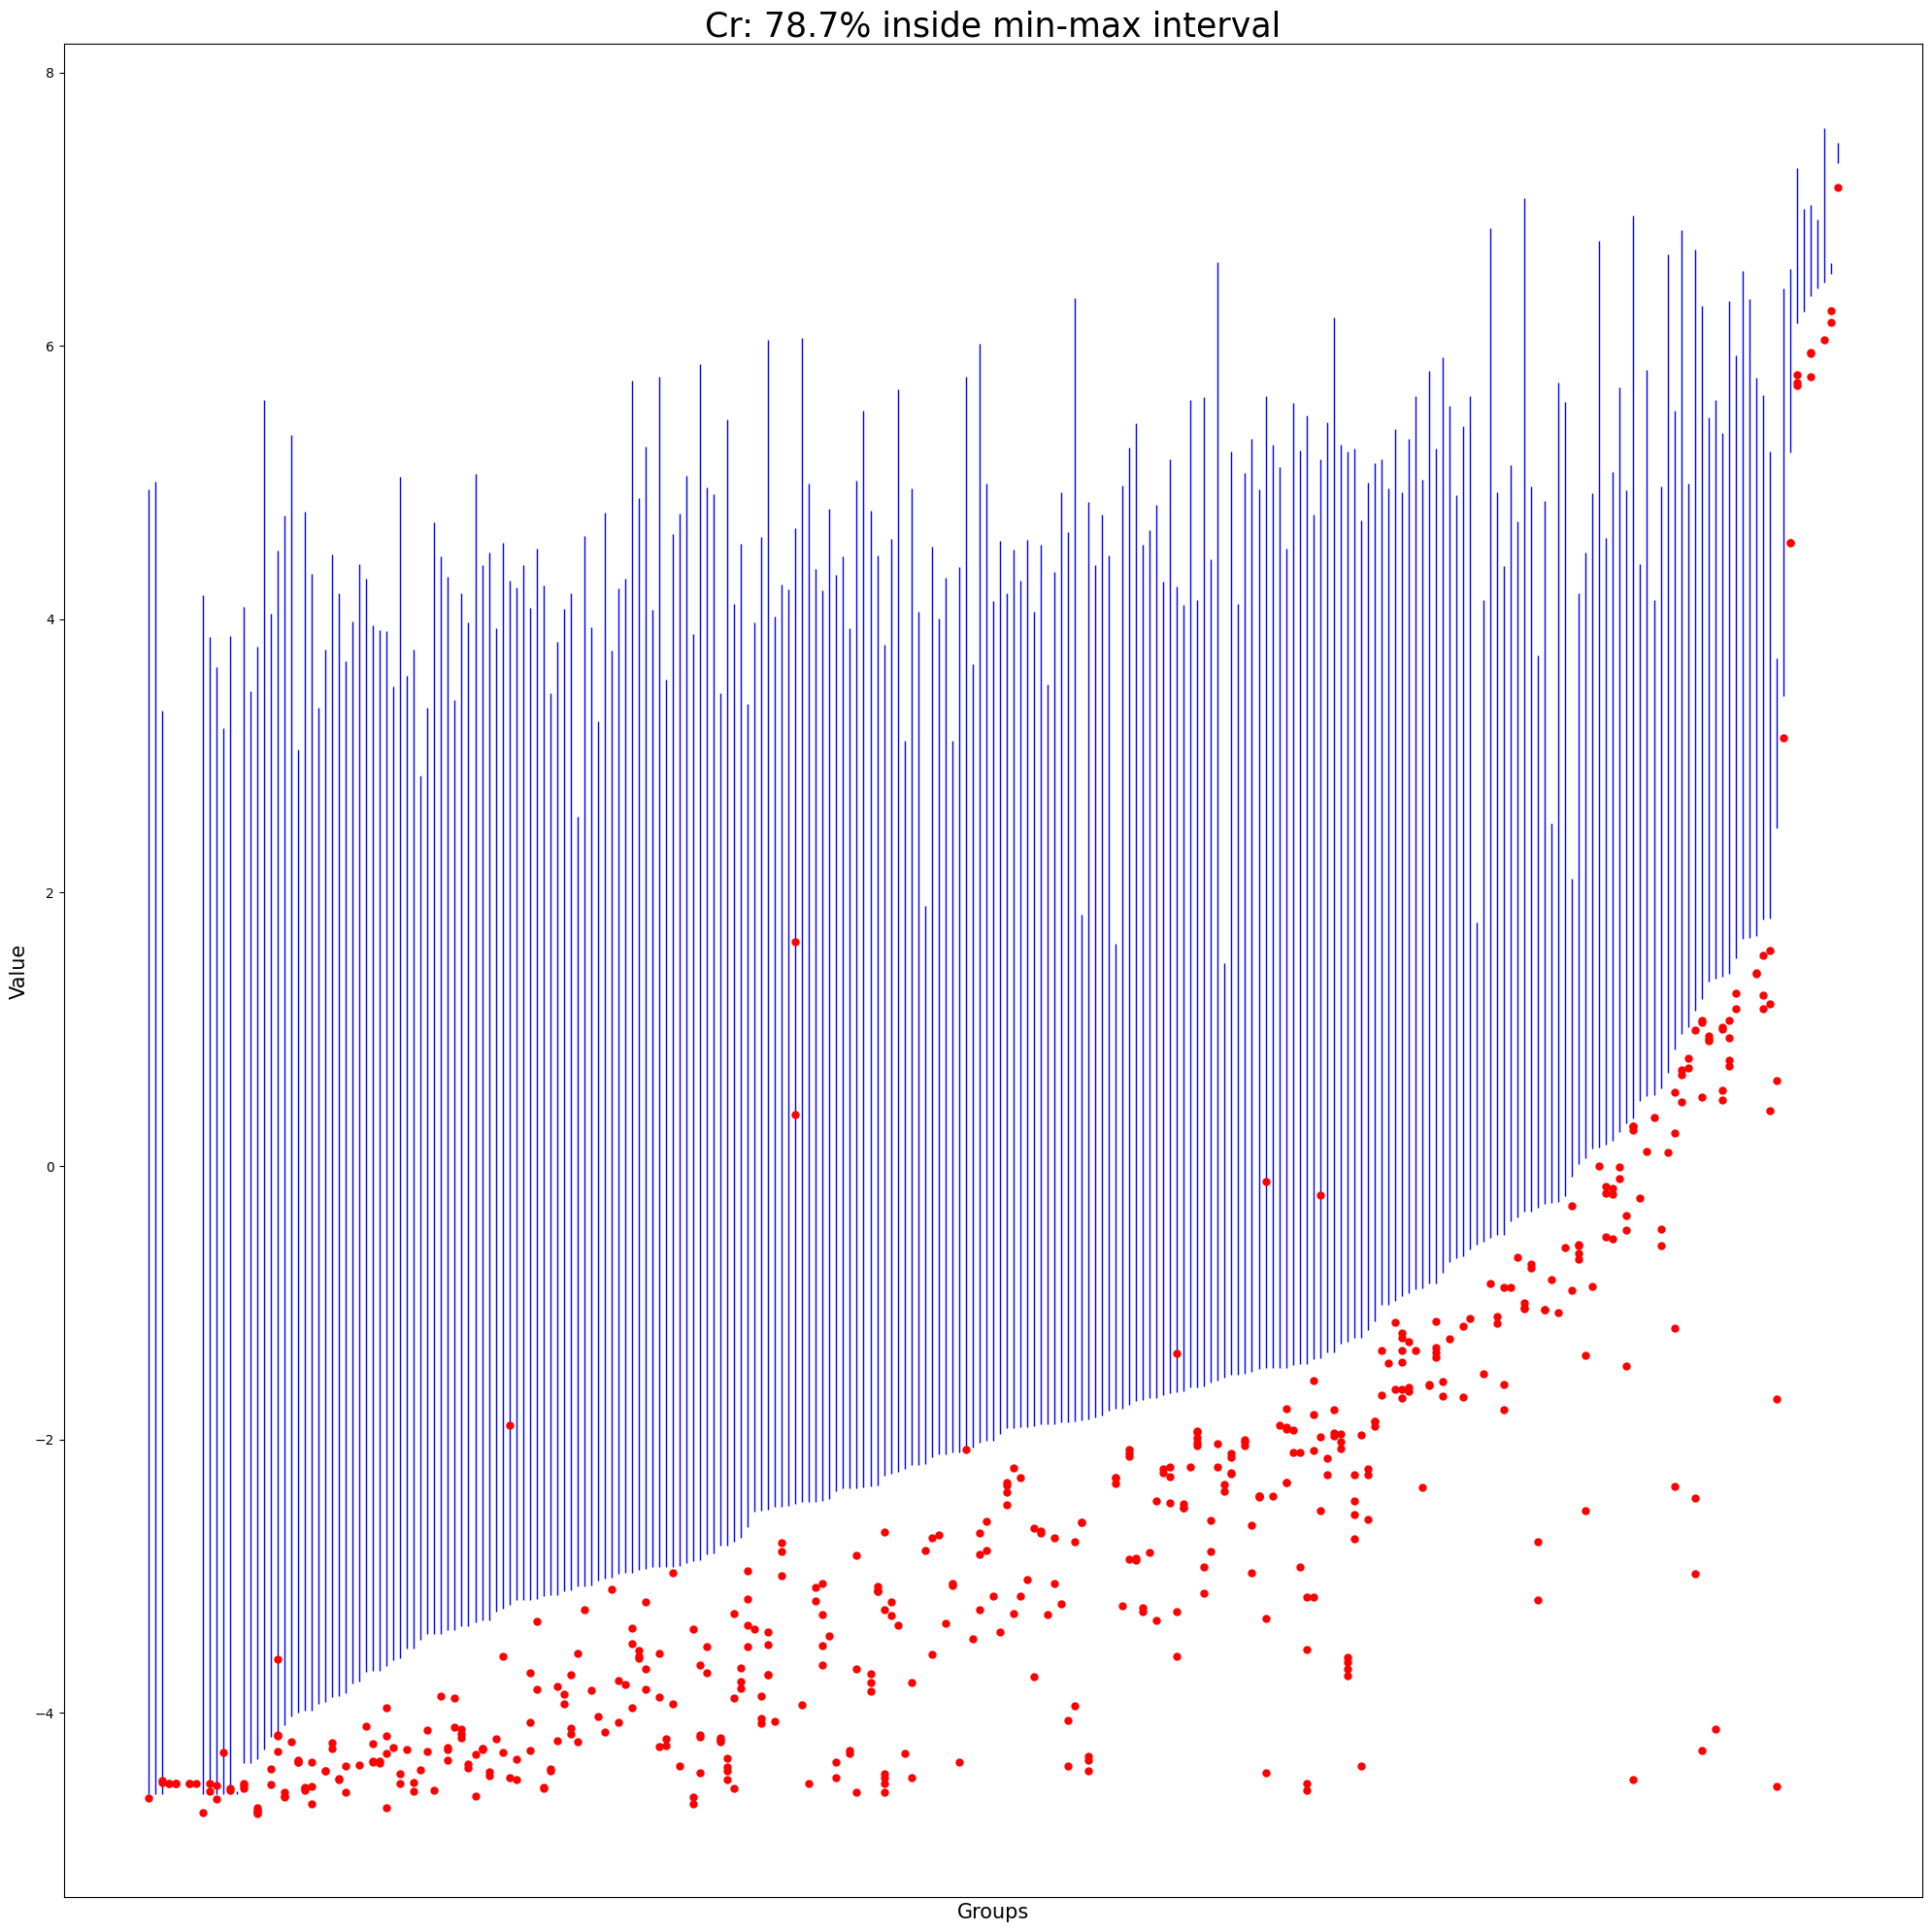

In [83]:
element = 2
percentage_correct = np.round(100*(np.array(min_max_res_list).mean(0))[0,element], 1)

sorted_min_max_df = min_max_df.sort_values(min_max_df.columns[element+1])
sorted_min_max_df.reset_index(drop=True, inplace=True)

for sample_id in range(sorted_min_max_df.shape[0]):
    plt.vlines(x=sample_id, ymin=sorted_min_max_df.iloc[sample_id, element+9], 
                  ymax=sorted_min_max_df.iloc[sample_id, element+1], 
                  color="blue", linewidth=1)

for row in range(outputs_df.shape[0]):
    new_index = sorted_min_max_df[sorted_min_max_df['Sample_id']==outputs_df['Real sample_id'][row]].index
    plt.plot(new_index, outputs_df.iloc[row,element+1], 'ro', markersize=5)
        
plt.xticks([], [])
plt.xlabel('Groups',size=15)
plt.ylabel('Value',size=15)
plt.title(str(outputs_df.columns[element+1]) + ': '+str(percentage_correct) +'% inside min-max interval', size=25)
plt.rcParams['figure.figsize'] = [20, 20]
plt.tight_layout()

#plt.savefig('../figures/min_max_intervals_'+str(outputs_df.columns[element+1]))

## Interpretability